<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-bottom: 2px solid #333; padding-bottom: 12px; margin-bottom: 20px;">
    <h1 style="margin: 0 0 6px 0; font-size: 24px; color: #111;">air-quality-cleaning.ipynb</h1>
    <div style="font-size: 13px; color: #555;">
        <span><strong>Project:</strong> NYC Air Quality Public Health Data Analysis</span> &nbsp;&bull;&nbsp; 
        <span><strong>Author:</strong> Kathryn Penrod</span> &nbsp;&bull;&nbsp; 
        <span><strong>Goal:</strong> Data Cleaning</span>
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

In [2]:
#upload the data file 
air_df = pd.read_csv('Air_Quality.csv') 
conn=sqlite3.connect('Air_Quality.csv') 
#check that it was uploaded 
air_df.head(n = 3) 

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,166657,375,Nitrogen dioxide (NO2),Mean,ppb,CD,310,Bay Ridge and Dyker Heights (CD10),Summer 2009,6/1/2009,20.38,NaN
1,167778,375,Nitrogen dioxide (NO2),Mean,ppb,CD,310,Bay Ridge and Dyker Heights (CD10),Annual Average 2013,12/1/2012,19.48,NaN
2,165890,375,Nitrogen dioxide (NO2),Mean,ppb,CD,310,Bay Ridge and Dyker Heights (CD10),Winter 2010-11,12/1/2010,29.44,NaN


In [3]:
#Change data types (not dates yet though)
air_df['Unique ID'].apply(int) 
air_df['Indicator ID'].apply(int) 
air_df['Name'].apply(str) 
air_df['Measure'].apply(str) 
air_df['Measure Info'].apply(str) 
air_df['Geo Type Name'].apply(str) 
air_df['Geo Join ID'].apply(int) 
air_df['Geo Place Name'].apply(str) 
air_df['Time Period'].apply(str) 
air_df['Data Value'].apply(float)

0        20.380000
1        19.480000
2        29.440000
3        18.080000
4        18.060000
           ...    
18857    99.945442
18858     5.860954
18859    32.765812
18860    26.360000
18861    28.580000
Name: Data Value, Length: 18862, dtype: float64

In [4]:
#convert start_date column to date format
#air_df['Start_Date'] = pd.to_datetime(air_df['Start_Date'])

In [5]:
#change seasons to dates
seasons = {
    'Winter': ('12-01', '02-28'),
    'Spring': ('03-01', '05-31'),
    'Summer': ('06-01', '08-31'),
    'Fall': ('09-01', '11-30'),
    'Autumn': ('09-01', '11-30'),
}


def parse_time_period(val):
  if pd.isna(val):
    return pd.Series([pd.NaT, pd.NaT])

  val = str(val).strip()

  # Extract the first 4-digit year in the string
  match = re.search(r'\b\d{4}\b', val) or re.search(r'\d{4}', val)
  base_year = match.group(0) if match else None

  #Handle Year Ranges
  if '-' in val and 'winter' not in val.lower():
    parts = val.split('-')
    if len(parts) == 2:
      start_yr = parts[0].strip()
      end_yr = parts[1].strip()

      # If base_year was not captured yet, pull from start_yr
      if not base_year:
        m = re.search(r'\d{4}', start_yr)
        base_year = m.group(0) if m else None

      if base_year:
        if len(end_yr) == 2:
          end_yr = base_year[:2] + end_yr
        return pd.Series([f'{base_year}-01-01', f'{end_yr}-12-31'])

  #Handle Seasons
  for season, (start_md, end_md) in seasons.items():
    if season.lower() in val.lower():
      if base_year:
        end_year = (
            int(base_year) + 1 if season.lower() == 'winter' else base_year
        )
        return pd.Series([f'{base_year}-{start_md}', f'{end_year}-{end_md}'])

  #Handle Single 4-digit Years (e.g., "2015")
  if val.isdigit() and len(val) == 4:
    return pd.Series([f'{val}-01-01', f'{val}-12-31'])

  #Handle Standard Dates (e.g., "December 2013")
  dt = pd.to_datetime(val, errors='coerce')
  if pd.isna(dt):
    return pd.Series([pd.NaT, pd.NaT])

  start = dt.strftime('%Y-%m-01')
  end = (dt + pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')
  return pd.Series([start, end])


# Apply to the df
dates_df = air_df['Time Period'].apply(parse_time_period)
air_df['start_date'] = pd.to_datetime(dates_df[0])
air_df['end_date'] = pd.to_datetime(dates_df[1])

In [6]:
#combine Start_Date and start_date
air_df['start_date'] = air_df['start_date'].combine_first(air_df['Start_Date'])
air_df.drop(columns=['Start_Date'], inplace=True)

In [7]:
#check variables for errors/duplicates

cols = ['Name', 'Measure', 'Measure Info', 'Geo Type Name']
unique_vars = np.sort(pd.unique(air_df[cols].values.ravel()))
print(unique_vars)

['Annual average concentration' 'Annual vehicle miles traveled'
 'Annual vehicle miles traveled (cars)'
 'Annual vehicle miles traveled (trucks)'
 'Asthma emergency department visits due to PM2.5'
 'Asthma emergency departments visits due to Ozone'
 'Asthma hospitalizations due to Ozone'
 'Boiler Emissions- Total NOx Emissions'
 'Boiler Emissions- Total PM2.5 Emissions'
 'Boiler Emissions- Total SO2 Emissions' 'Borough' 'CD'
 'Cardiac and respiratory deaths due to Ozone'
 'Cardiovascular hospitalizations due to PM2.5 (age 40+)' 'Citywide'
 'Deaths due to PM2.5' 'Estimated annual rate'
 'Estimated annual rate (age 18+)' 'Estimated annual rate (age 30+)'
 'Estimated annual rate (under age 18)' 'Fine particles (PM 2.5)' 'Mean'
 'Million miles' 'Nitrogen dioxide (NO2)' 'Number per km2'
 'Outdoor Air Toxics - Benzene' 'Outdoor Air Toxics - Formaldehyde'
 'Ozone (O3)' 'Respiratory hospitalizations due to PM2.5 (age 20+)'
 'UHF34' 'UHF42' 'mcg/m3' 'number' 'per 100,000' 'per 100,000 adults'
 

In [8]:
#fix the Âµg/m3 label
air_df['Measure Info'] = air_df['Measure Info'].replace(['Âµg/m3'], 'mcg/m3')

In [9]:
#drop duplicates & locate empty cells 
clean_df = air_df.drop_duplicates(subset= 
['Indicator ID', 'Geo Place Name', 'Time Period', 'Data Value']) 
air_df.isna().sum() 

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Data Value            0
Message           18862
start_date            0
end_date           4230
dtype: int64

In [10]:
#look at the data with less noise 
clean_df=clean_df.drop(columns=[ 
'Unique ID','Indicator ID','Message','Geo Join ID','Geo Type Name', 'Measure', 'Measure Info']) 
        #Remaining columns: 
        ##'Name', 'Geo Place Name', 'Time Period', 'Data Value', 'Start_Date'
clean_df.head(5) 

,Name,Geo Place Name,Time Period,Data Value,start_date,end_date
0,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2009,20.38,2009-06-01,2009-08-31
1,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Annual Average 2013,19.48,2012-12-01,NaT
2,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Winter 2010-11,29.44,2010-12-01,2011-02-28
3,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2010,18.08,2010-06-01,2010-08-31
4,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2011,18.06,2011-06-01,2011-08-31


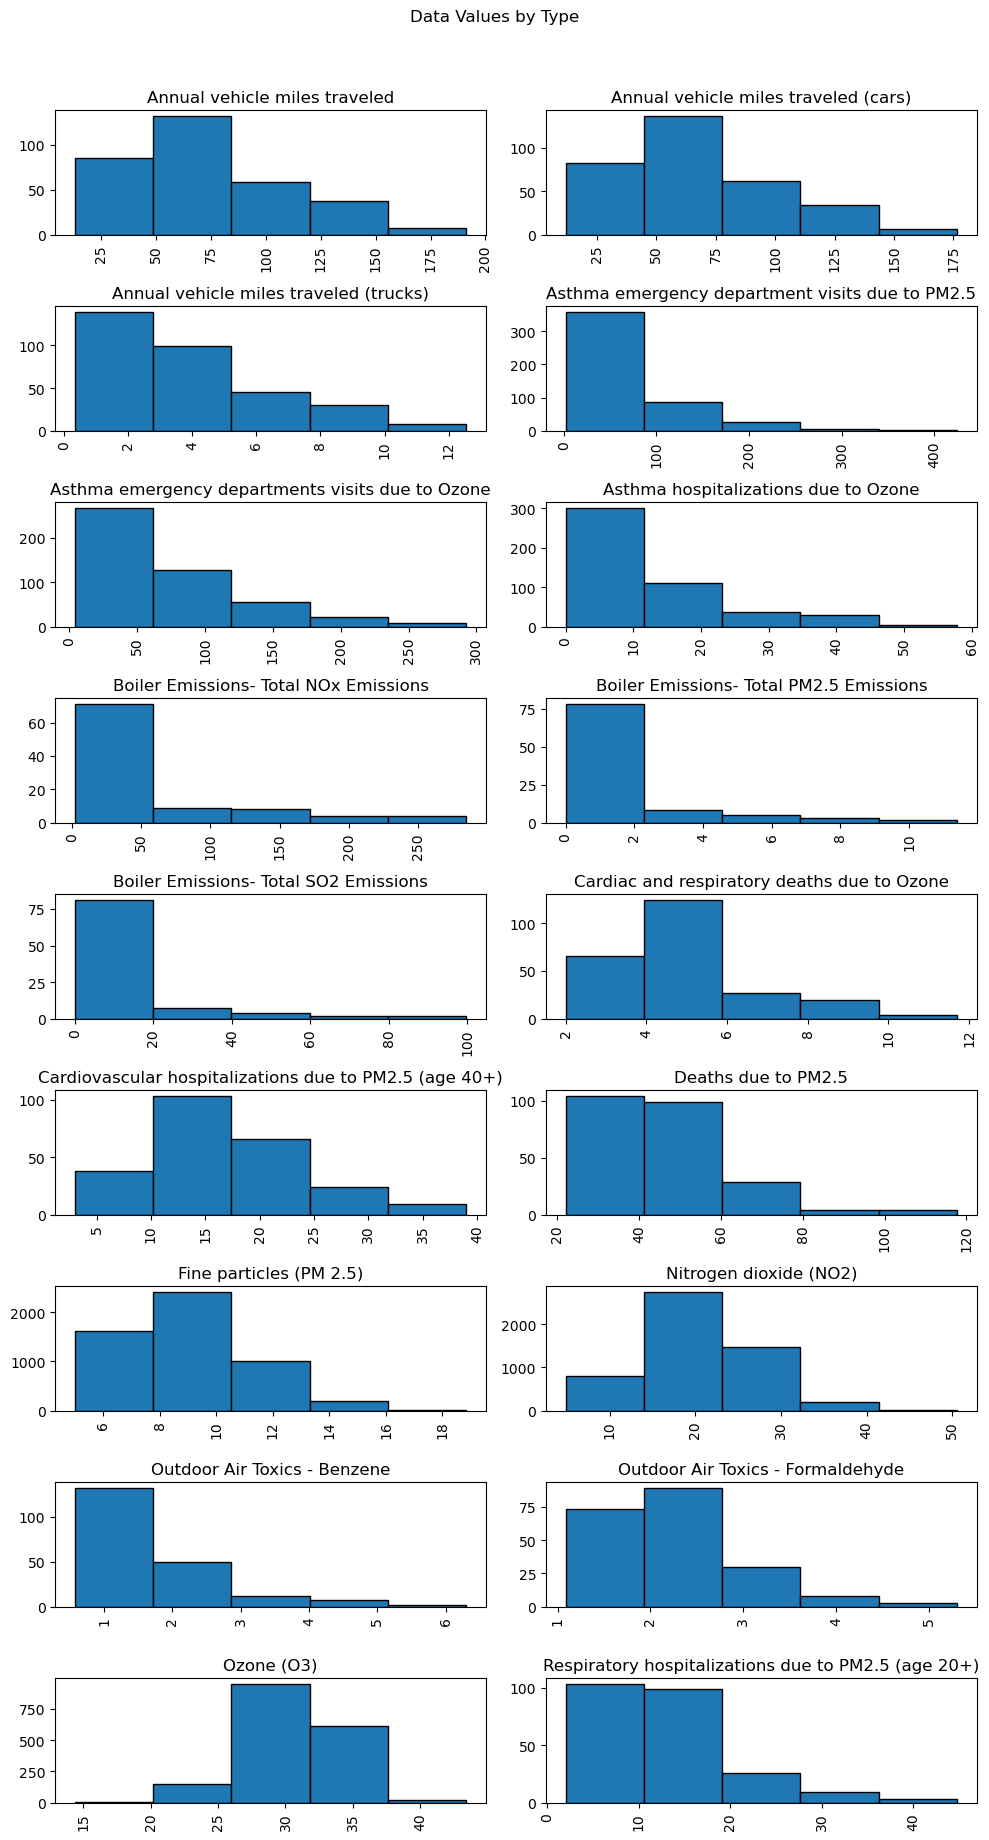

In [11]:
#make histogram to check for outliers 
#y axis is value counts, x is Data Value 
clean_df.hist(column='Data Value', by='Name', bins=5, edgecolor='black', figsize=(10, 18), layout=(9,2))  
plt.suptitle("Data Values by Type", y=1.02)  
plt.subplots_adjust(hspace=0.8, wspace=0.4) 
plt.tight_layout() 
plt.show() 

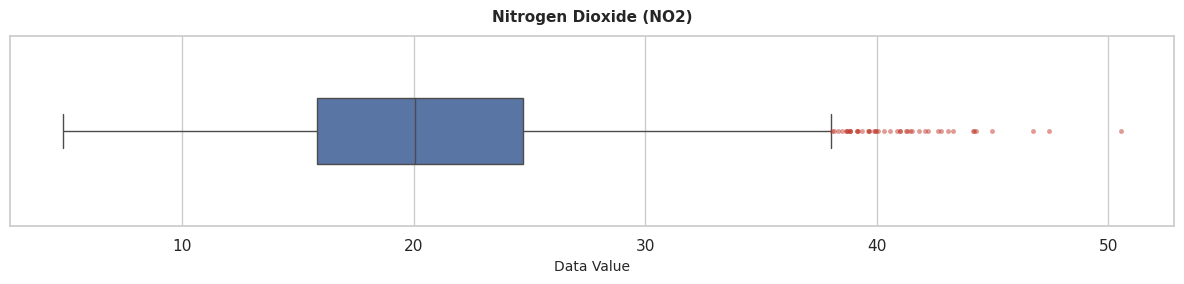

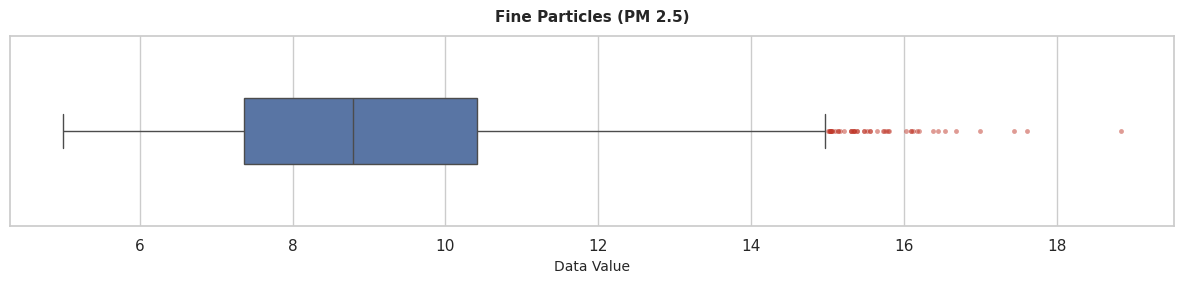

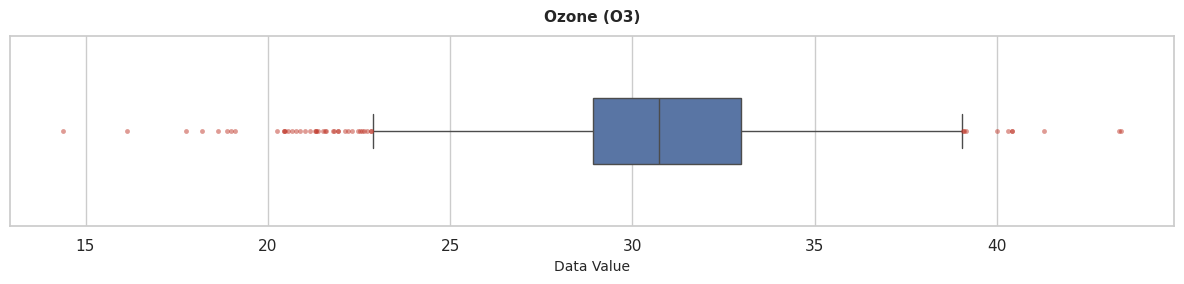

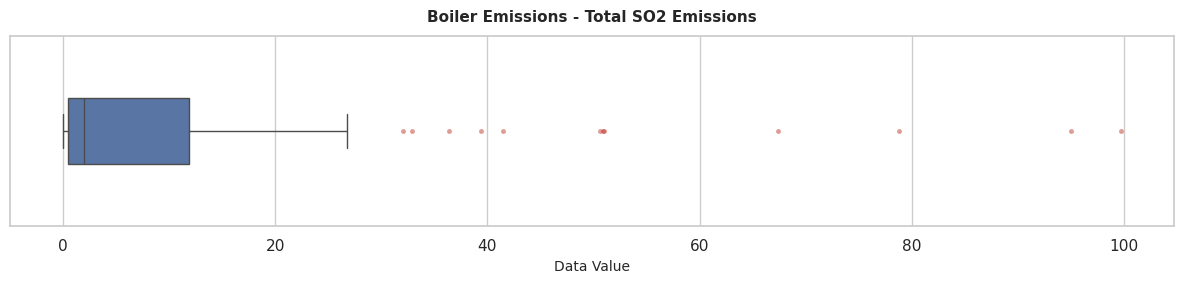

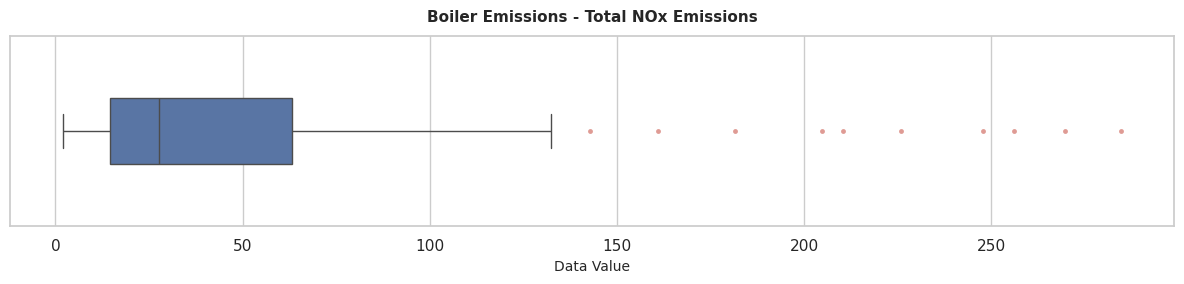

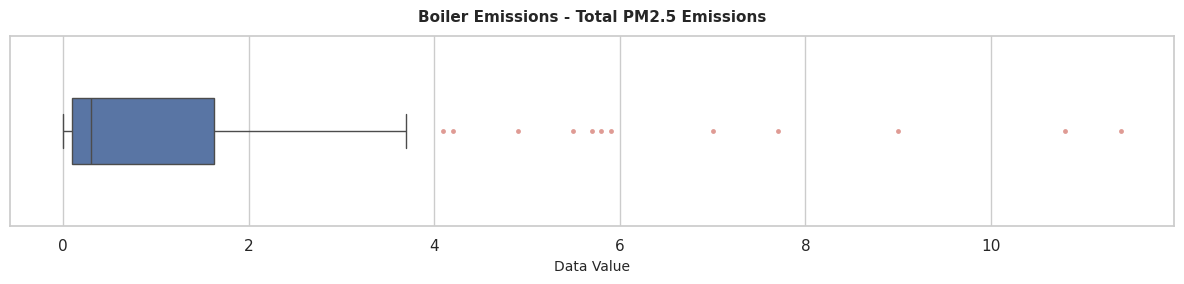

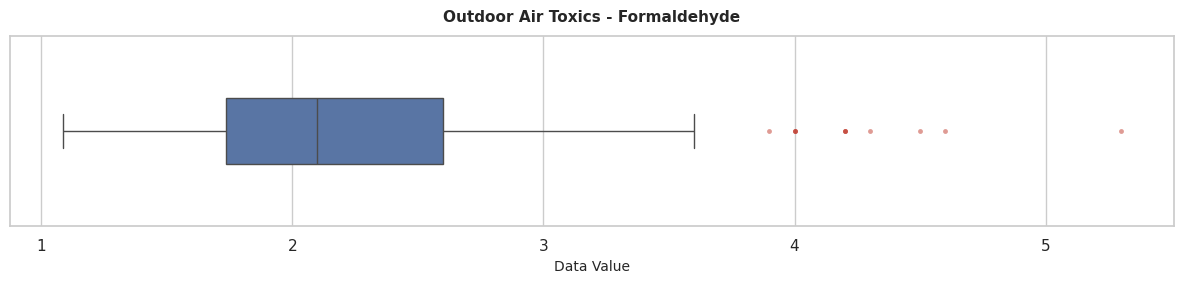

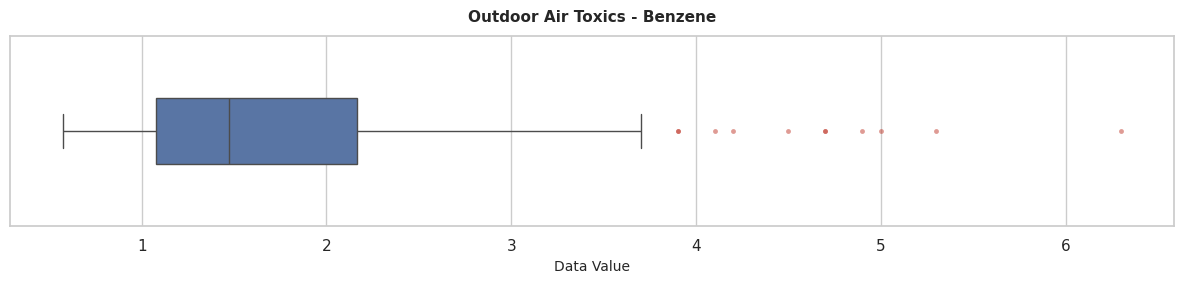

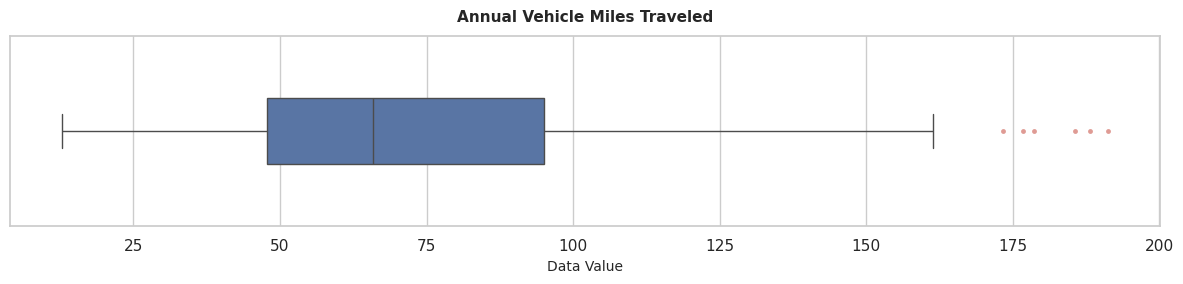

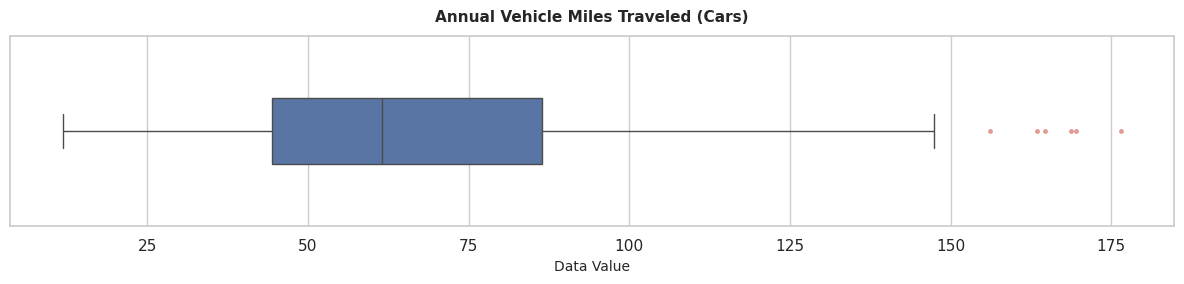

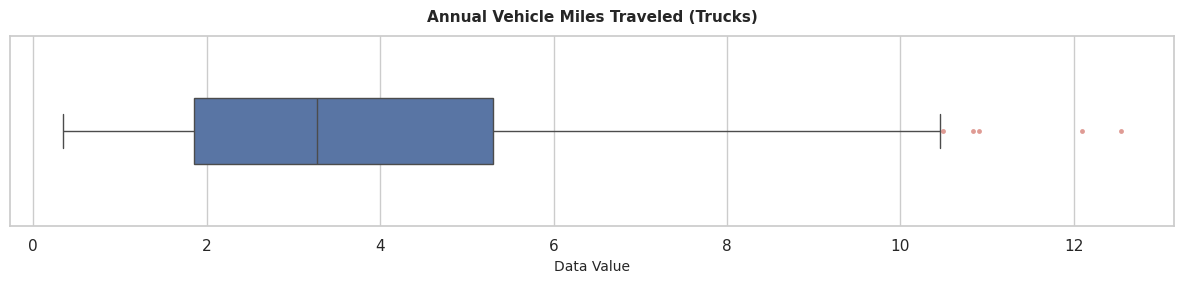

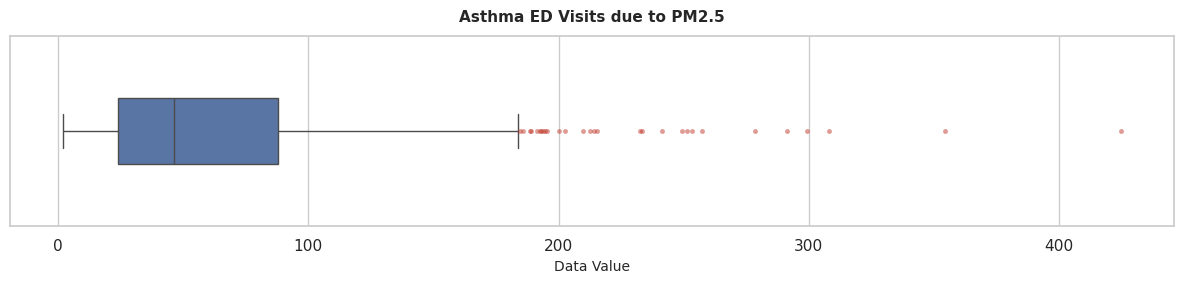

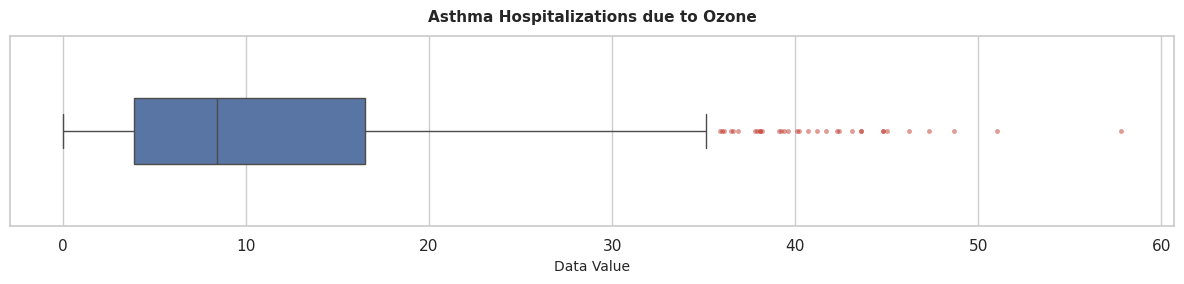

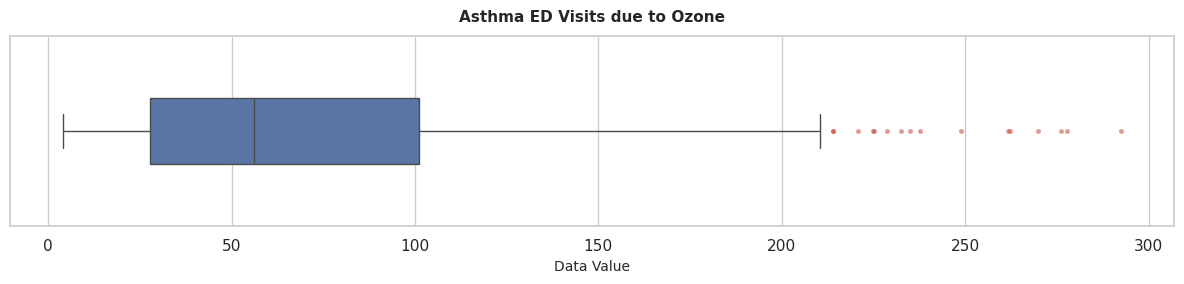

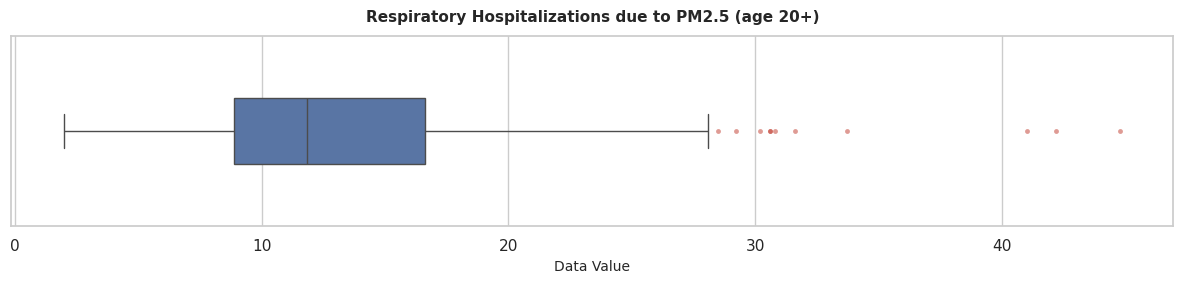

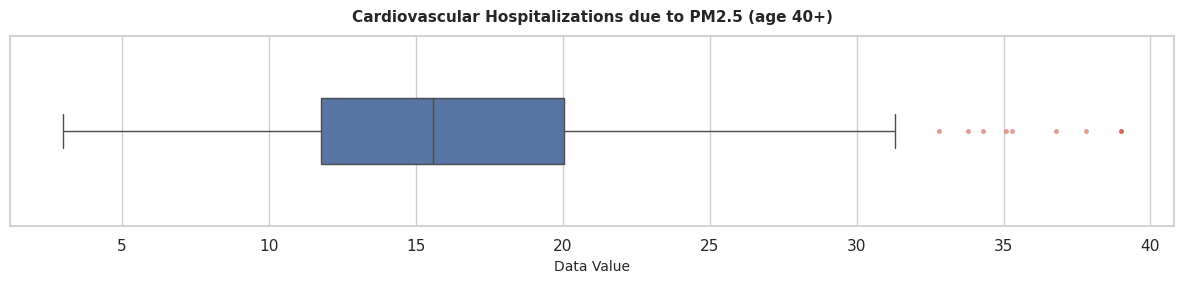

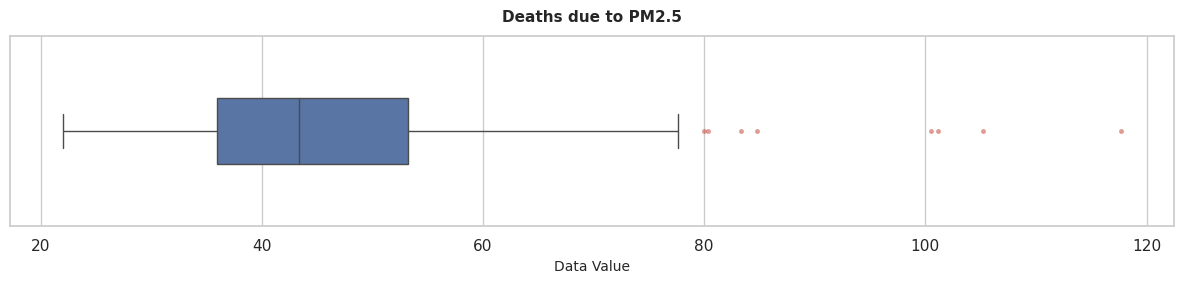

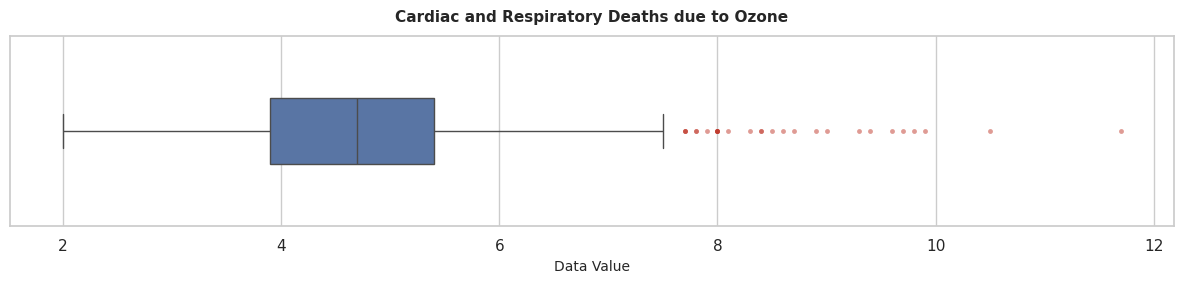

In [12]:
#whisker plot to check for outliers

sns.set_theme(style="whitegrid")
target_variables = {
    'Nitrogen Dioxide (NO2)': 'Nitrogen dioxide (NO2)',
    'Fine Particles (PM 2.5)': 'Fine particles (PM 2.5)',
    'Ozone (O3)': 'Ozone (O3)',
    'Boiler Emissions - Total SO2 Emissions': (
        'Boiler Emissions- Total SO2 Emissions'
    ),
    'Boiler Emissions - Total NOx Emissions': (
        'Boiler Emissions- Total NOx Emissions'
    ),
    'Boiler Emissions - Total PM2.5 Emissions': (
        'Boiler Emissions- Total PM2.5 Emissions'
    ),
    'Outdoor Air Toxics - Formaldehyde': 'Outdoor Air Toxics - Formaldehyde',
    'Outdoor Air Toxics - Benzene': 'Outdoor Air Toxics - Benzene',
    'Annual Vehicle Miles Traveled': 'Annual vehicle miles traveled',
    'Annual Vehicle Miles Traveled (Cars)': (
        'Annual vehicle miles traveled (cars)'
    ),
    'Annual Vehicle Miles Traveled (Trucks)': (
        'Annual vehicle miles traveled (trucks)'
    ),
    'Asthma ED Visits due to PM2.5': (
        'Asthma emergency department visits due to PM2.5'
    ),
    'Asthma Hospitalizations due to Ozone': (
        'Asthma hospitalizations due to Ozone'
    ),
    'Asthma ED Visits due to Ozone': (
        'Asthma emergency departments visits due to Ozone'
    ),
    'Respiratory Hospitalizations due to PM2.5 (age 20+)': (
        'Respiratory hospitalizations due to PM2.5 (age 20+)'
    ),
    'Cardiovascular Hospitalizations due to PM2.5 (age 40+)': (
        'Cardiovascular hospitalizations due to PM2.5 (age 40+)'
    ),
    'Deaths due to PM2.5': 'Deaths due to PM2.5',
    'Cardiac and Respiratory Deaths due to Ozone': (
        'Cardiac and respiratory deaths due to Ozone'
    ),
}

for title, exact_name in target_variables.items():
  subset = clean_df[clean_df['Name'] == exact_name]

  if subset.empty:
    print(f"Skipping '{title}': No matching rows found for '{exact_name}'")
    continue

  plt.figure(figsize=(12, 3))

  sns.boxplot(
      data=subset,
      x='Data Value',
      color='#4C72B0',
      width=0.35,
      fliersize=3.5,
      flierprops={
          'markerfacecolor': '#C0392B',
          'markeredgecolor': 'none',
          'alpha': 0.5,
      },
  )

  plt.title(title, fontsize=11, fontweight='bold', pad=10)
  plt.xlabel('Data Value', fontsize=10)
  plt.yticks([])

  plt.tight_layout()
  plt.show()

In [13]:
#Environmental Pollutants 
no2_df = clean_df[clean_df["Name"] == "Nitrogen dioxide (NO2)"] 
pm25_df = clean_df[clean_df["Name"] == "Fine particles (PM 2.5)"] 
ozone_df = clean_df[clean_df["Name"] == "Ozone (O3)"] 

#Boiler & Industrial Emissions 
so2_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total SO2 Emissions"] 
nox_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total NOx Emissions"] 
pm25_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total PM2.5 Emissions"] 

#Outdoor Air Toxins 
form_df = clean_df[clean_df["Name"] == "Outdoor Air Toxins - Formaldehyde"] 
benz_df = clean_df[clean_df["Name"] == "Outdoor Air Toxins - Benzene"] 

#Traffic & Vehicle Metrics 
vmt_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled"] 
vmt_cars_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled (cars)"] 
vmt_trck_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled (trucks)"] 

#Health: Asthma 
asth_pm_df = clean_df[clean_df["Name"] == "Asthma emergency department visits due to PM2.5"] 
asth_oz_h_df= clean_df[clean_df["Name"] == "Asthma hospitalizations due to Ozone"] 
asth_oz_ed_df= clean_df[clean_df["Name"] == "Asthma emergency departments visits due to Ozone"] 

#Health: everything else
resp_df = clean_df[clean_df["Name"] == "Respiratory hospitalizations due to PM2.5 (age 20+)"] 
cardio_df = clean_df[clean_df["Name"] == "Cardiovascular hospitalizations due to PM2.5 (age 40+)"] 
deaths_pm_df= clean_df[clean_df["Name"] == "Deaths due to PM2.5"] 
deaths_oz_df= clean_df[clean_df["Name"] == "Cardiac and respiratory deaths due to Ozone"] 

In [14]:
#label each variable
name_mapping = {
    "Nitrogen dioxide (NO2)": "NO2 Levels",
    "Fine particles (PM 2.5)": "PM2.5 Levels",
    "Boiler Emissions- Total SO2 Emissions": "Boiler SO2",
    "Ozone (O3)": "Ozone Levels",
    "Asthma emergency department visits due to PM2.5": "Asthma ED (PM2.5)",
    "Annual vehicle miles traveled": "VMT Total",
    "Respiratory hospitalizations due to PM2.5 (age 20+)": "Resp Hosp (PM2.5)",
    "Asthma hospitalizations due to Ozone": "Asthma Hosp (Ozone)",
    "Boiler Emissions- Total NOx Emissions": "Boiler NOx",
    "Boiler Emissions- Total PM2.5 Emissions": "Boiler PM2.5",
    "Outdoor Air Toxics - Formaldehyde": "Formaldehyde",
    "Outdoor Air Toxics - Benzene": "Benzene",
    "Asthma emergency departments visits due to Ozone": "Asthma ED (Ozone)",
    "Annual vehicle miles traveled (cars)": "VMT Cars",
    "Annual vehicle miles traveled (trucks)": "VMT Trucks",
    "Cardiovascular hospitalizations due to PM2.5 (age 40+)": (
        "Cardio Hosp (PM2.5)"
    ),
    "Deaths due to PM2.5": "Deaths (PM2.5)",
    "Cardiac and respiratory deaths due to Ozone": "Deaths (Ozone)",
}

clean_df["Name"] = clean_df["Name"].replace(name_mapping)

pivoted_df = clean_df.pivot_table(
    index="Geo Place Name", columns="Name", values="Data Value", aggfunc="mean"
)

In [15]:
all_dfs = {
    "pivoted_df" : pivoted_df,
    "clean_df": clean_df,
    "Nitrogen Dioxide (NO2)": no2_df,
    "Fine Particles (PM2.5)": pm25_df,
    "Ozone (O3)": ozone_df,
    "Boiler Emissions - Total SO2": so2_em_df,
    "Boiler Emissions - Total NOx": nox_em_df,
    "Boiler Emissions - Total PM2.5": pm25_em_df,
    "Air Toxins - Formaldehyde": form_df,
    "Air Toxins - Benzene": benz_df,
    "Annual VMT (Total)": vmt_df,
    "Annual VMT (Cars)": vmt_cars_df,
    "Annual VMT (Trucks)": vmt_trck_df,
    "Asthma ED Visits due to PM2.5": asth_pm_df,
    "Asthma Hospitalizations due to Ozone": asth_oz_h_df,
    "Asthma ED Visits due to Ozone": asth_oz_ed_df,
    "Respiratory Hospitalizations due to PM2.5 (Age 20+)": resp_df,
    "Cardiovascular Hospitalizations due to PM2.5 (Age 40+)": cardio_df,
    "Deaths due to PM2.5": deaths_pm_df,
    "Cardiac & Respiratory Deaths due to Ozone": deaths_oz_df,
}

In [16]:
#Pickle
pd.to_pickle(all_dfs, 'all_clean_dfs.pkl')